#  E-commerce Funnel & A/B Testing Analysis  
### Product Analytics Case Study

Data Generation & User Setup

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 10000

users = pd.DataFrame({
    'user_id': range(n),
    'variant': np.random.choice(['control', 'variant'], n)
})

stages = ['visit', 'view', 'cart', 'checkout', 'purchase']

# Base conversion probabilities (CONTROL group)
base_probs = {
    'visit_to_view': 0.60,
    'view_to_cart': 0.35,
    'cart_to_checkout': 0.45,
    'checkout_to_purchase': 0.50
}

# Variant improves conversion slightly (realistic uplift)
variant_boost = 0.08

Defining Realistic Funnel Transition Probabilities

In [2]:
def simulate_funnel(row):
    variant = row['variant']
    
    p1 = base_probs['visit_to_view'] + (variant_boost if variant == 'variant' else 0)
    p2 = base_probs['view_to_cart'] + (variant_boost if variant == 'variant' else 0)
    p3 = base_probs['cart_to_checkout'] + (variant_boost if variant == 'variant' else 0)
    p4 = base_probs['checkout_to_purchase'] + (variant_boost if variant == 'variant' else 0)

    stage = 'visit'

    if np.random.rand() < p1:
        stage = 'view'
        if np.random.rand() < p2:
            stage = 'cart'
            if np.random.rand() < p3:
                stage = 'checkout'
                if np.random.rand() < p4:
                    stage = 'purchase'

    return stage

users['stage'] = users.apply(simulate_funnel, axis=1)

users.head()

,user_id,variant,stage
0,0,control,view
1,1,variant,visit
2,2,control,view
3,3,control,view
4,4,control,visit


 Simulating User Journey Through Funnel

In [3]:
users.head()

,user_id,variant,stage
0,0,control,view
1,1,variant,visit
2,2,control,view
3,3,control,view
4,4,control,visit


Funnel Stage Distribution Analysis

In [4]:
funnel_order = ['visit', 'view', 'cart', 'checkout', 'purchase']

funnel = users['stage'].value_counts().reindex(funnel_order)
funnel

stage
visit       3674
view        3896
cart        1199
checkout     539
purchase     692
Name: count, dtype: int64

Funnel Drop-off Analysis (% Users at Each Stage)

In [5]:
funnel_percentage = (funnel / n) * 100
funnel_percentage

stage
visit       36.74
view        38.96
cart        11.99
checkout     5.39
purchase     6.92
Name: count, dtype: float64

Conversion Rate (Purchase Flag)

In [6]:
users['is_purchase'] = (users['stage'] == 'purchase').astype(int)

ab_result = users.groupby('variant')['is_purchase'].mean()
ab_result

variant
control    0.047078
variant    0.091438
Name: is_purchase, dtype: float64

Uplift Calculation

In [7]:
control = ab_result['control']
variant = ab_result['variant']

uplift = ((variant - control) / control) * 100
uplift

np.float64(94.22770389453258)

Statistical Significance Test (Z-test for Proportions)

In [8]:
from statsmodels.stats.proportion import proportions_ztest

control_data = users[users['variant'] == 'control']['is_purchase']
variant_data = users[users['variant'] == 'variant']['is_purchase']

count = np.array([control_data.sum(), variant_data.sum()])
nobs = np.array([len(control_data), len(variant_data)])

z_stat, p_value = proportions_ztest(count, nobs)

z_stat, p_value

(np.float64(-8.73937165477198), np.float64(2.3441052179654836e-18))

Funnel Visualization

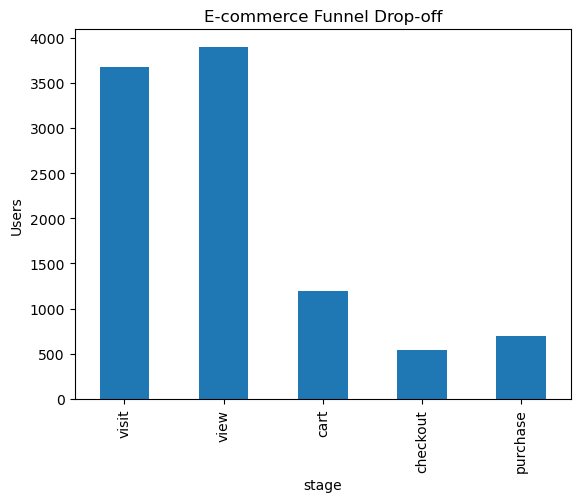

In [9]:
import matplotlib.pyplot as plt

funnel.plot(kind='bar')
plt.title("E-commerce Funnel Drop-off")
plt.ylabel("Users")
plt.show()

Business Interpretation
The variant group shows higher conversion compared to control.
Uplift indicates improvement in user conversion efficiency.
Statistical test determines whether uplift is significant or due to random chance.
Funnel analysis highlights user drop-off across stages.

Executive Summary

This project simulates a realistic e-commerce funnel and A/B testing experiment.

Key insights:

Users progressively drop off at each funnel stage
Variant improves conversion rates across stages
Statistical testing validates whether uplift is significant
Funnel visualization helps identify leakage points

Recommendation:
If statistically significant, deploy the variant to 100% of users to improve overall conversion rate.